# Titanic 6: Model Selection

## 1. Preprocessing Pipeline

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

# reading
url = "https://drive.google.com/file/d/1g3uhw_y3tboRm2eYDPfUzXXsw8IOYDCy/view?usp=sharing"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
data = pd.read_csv(path)

# X and y creation
X = data.drop(columns=["PassengerId", "Name", "Ticket"])
y = X.pop("Survived")

# Feature Engineering
X.loc[:, "Cabin"] = X.Cabin.str[0]

# data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# building the pipeline
num_features = X.select_dtypes(include="number").columns
cat_features = X.select_dtypes(exclude="number").columns

numeric_pipe = make_pipeline(
    SimpleImputer(strategy="mean"))

categoric_pipe = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="N_A"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessor = make_column_transformer(
    (numeric_pipe, num_features),
    (categoric_pipe, cat_features)
)

In [ ]:
y_train.value_counts()

,count
Survived,
0,435
1,277


In [ ]:
preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer())]),
                                 Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='N_A',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Sex', 'Cabin', 'Embarked'], dtype='object'))])

## 2. Modelling (Decision Tree)

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = make_pipeline(
    preprocessor,
    DecisionTreeClassifier()
)

param_grid = {
    "columntransformer__pipeline-1__simpleimputer__strategy":["mean", "median"],
    "decisiontreeclassifier__max_depth": range(2, 14, 2),
    "decisiontreeclassifier__min_samples_leaf": range(3, 12, 2)
}

search = GridSearchCV(full_pipeline,
                      param_grid,
                      cv=5,
                      verbose=1)

search.fit(X_train, y_train)

scores = {"dtree": search.best_score_}

scores

Fitting 5 folds for each of 60 candidates, totalling 300 fits


{'dtree': np.float64(0.8061656653205947)}

## 3. Error analysis

In [ ]:
# test accuracy
test_pred = search.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(test_acc)

0.8435754189944135


In [ ]:
# other metrics
from sklearn.metrics import recall_score, precision_score, f1_score, cohen_kappa_score

test_recall = recall_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_cohens_kappa= cohen_kappa_score(y_test, test_pred)

print(f"Test Accuracy: {round(test_acc, 3)}\nTest Recall: {round(test_recall, 3)}\nTest Precision: {round(test_precision, 3)}\nTest F1: {round(test_f1, 3)}\nTest Cohen's Kappa: {round(test_cohens_kappa, 3)}")

Test Accuracy: 0.844
Test Recall: 0.754
Test Precision: 0.803
Test F1: 0.778
Test Cohen's Kappa: 0.657


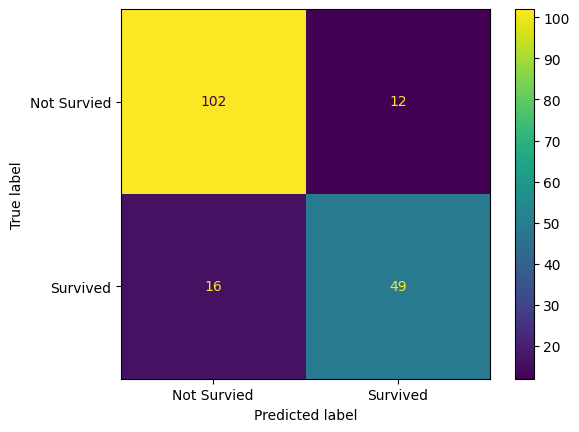

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
  search,
  X_test,
  y_test,
  display_labels=['Not Survied', 'Survived']
);

--- Final Model Evaluation ---
              precision    recall  f1-score   support

Not Survived       0.86      0.89      0.88       114
    Survived       0.80      0.75      0.78        65

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



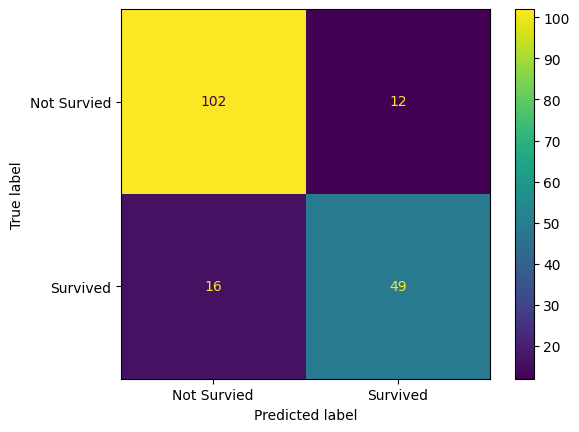

In [ ]:
# from sklearn.metrics import classification_report

# report = classification_report(y_test, test_pred, target_names=['Not Survived', 'Survived'])

# print("--- Final Model Evaluation ---")
# print(report)

# ConfusionMatrixDisplay.from_estimator(
#   search,
#   X_test,
#   y_test,
#   display_labels=['Not Survied', 'Survived']
# );

**Watch out!**

Scikit-learn presents confusion matrices in a way that might differ slightly from what you're used to.

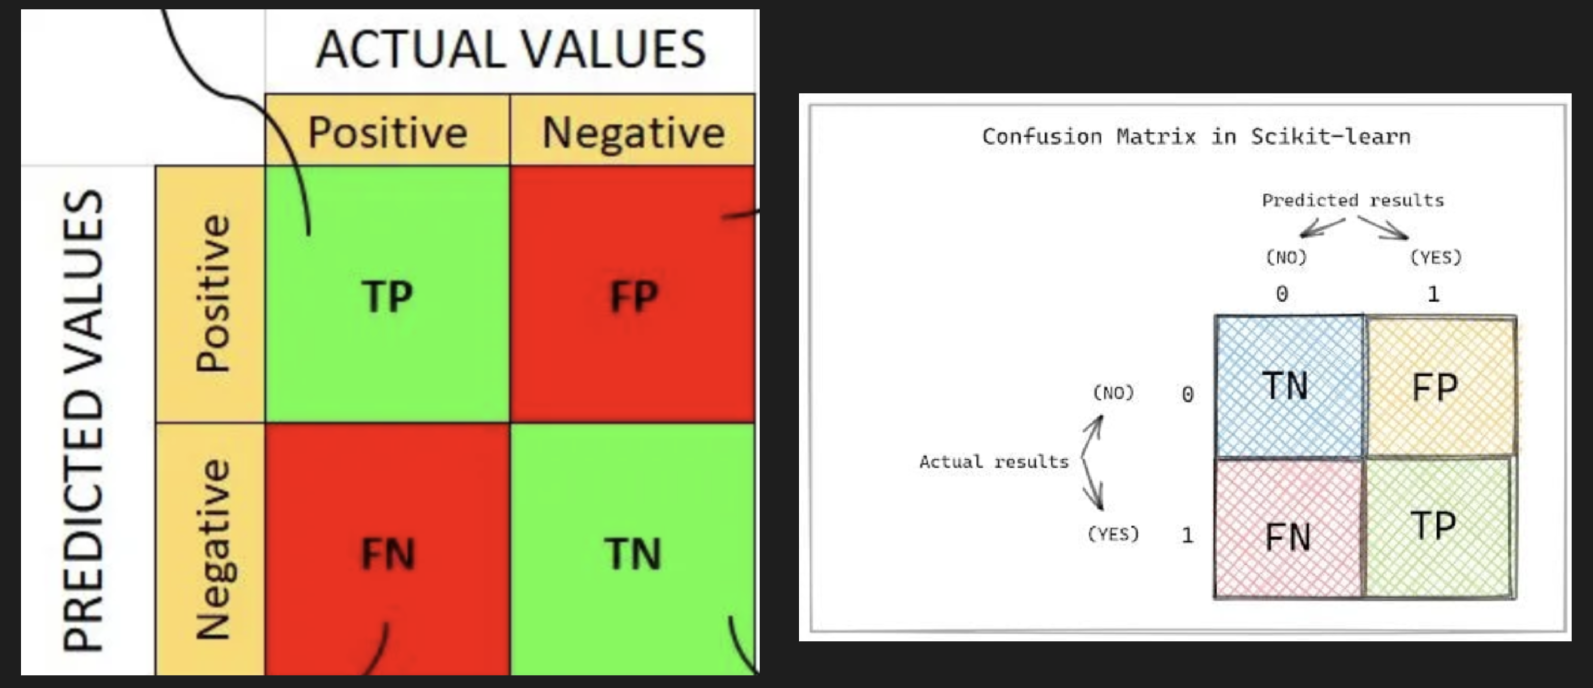

The [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) developers chose this layout because in binary classification, the "positive" class is typically labeled `1` and the "negative" class is labeled `0`. So when you think about it in terms of indexing, it makes sense that `C[0,0]` is the count of the true negatives and `C[1,1]` is the count of the true positives. The confusion matrix is laid out such that it matches the indexing of the output classes.

The [convention](https://builtin.com/data-science/confusion-matrix-python) is that the first index refers to the true class and the second index refers to the predicted class.

Therefore:
- `C[0,0]` corresponds to the count of the True Negatives, the top-left quadrant.
- `C[0,1]` corresponds to the count of False Positives, the top-right quadrant.
- `C[1,0]` corresponds to the count of False Negatives, the bottom-left quadrant.
- `C[1,1]` corresponds to the count of True Positives, the bottom-right quadrant.

### **Exercise 1:** build the same pipeline using a KNN instead of a decision tree.

> **Tip**: Check the SciKit-Learn documentation to find how to import the KNN model for this task and how to tune its hyperparameters (the names and possible values of the parameters).


In [ ]:
# your code here

## **Your challenge**

In a new notebook, apply everything you have learned here to the housing project, following the learning platform.